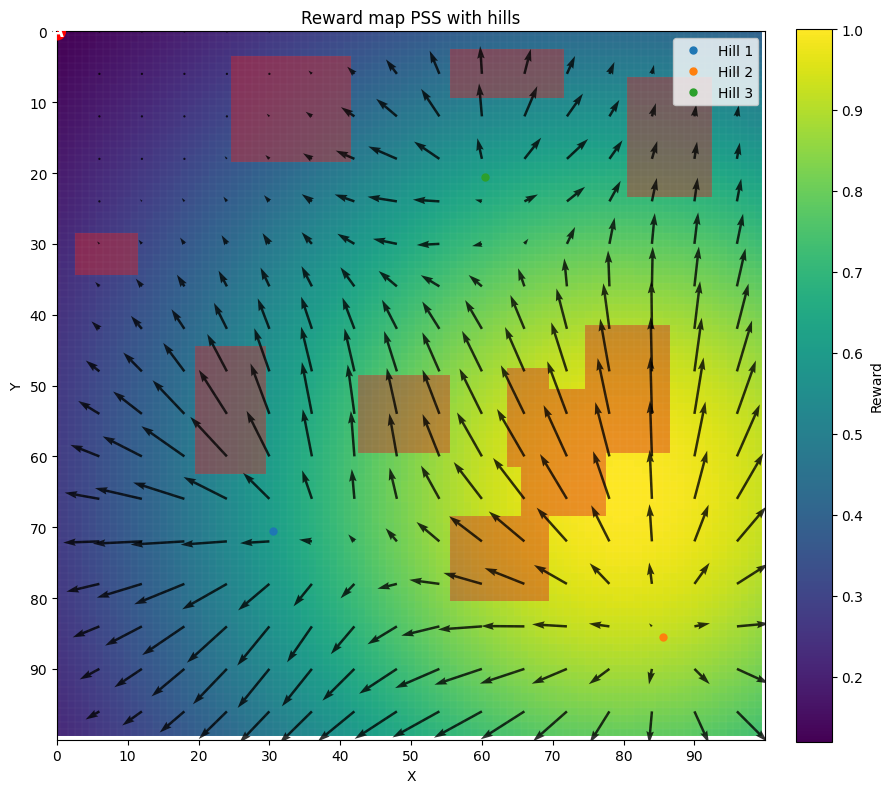

In [5]:
from pathlib import Path
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.stats import multivariate_normal
from tqdm import tqdm
import torch

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    )


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64, reward_scale=10.0, reward_gaussian_sigma=50.0)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_combined(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plot_agent(start_state, ax=ax)
plt.show()

max_x, max_y = env.grid_shape

actions = {
    'up': (0, -1),
    'right': (1, 0),
    'down': (0, 1),
    'left': (-1, 0),
}

states_visited = {start_state: 1}

In [6]:
def get_action(state, epsilon, q_values):
    if np.random.rand() < epsilon:
        action_index = np.random.choice(len(actions))
        action = list(actions.values())[action_index]  
    else:
        x, y = state
        action_index = np.argmax(q_values[x, y, :])
        action = list(actions.values())[action_index]
    return action, action_index

(x_top, y_top) = env.reward_gaussian_mean

def distance_to_goal(state):
    x, y = state
    return np.sqrt((x - x_top) ** 2 + (y - y_top) ** 2)

In [ ]:
# N samples x M tasks, (0,4) as we have not sampled yet
train_x = torch.empty((0, 4), dtype=torch.float64)
train_y = torch.empty((0, 2), dtype=torch.float64)

Q = np.zeros((max_x, max_y, len(actions)))  # 100 x 100 x 4
EPISODES = 2000
MAX_STEPS = 200
ALPHA = 0.3
GAMMA = 0.9
EPSILON = 1
EPSILON_DECAY = 0.9995
MIN_EPSILON = 0.1

# takes ~50 mins
# EPISODES = 2000
# MAX_STEPS = 1000
# ALPHA = 0.9
# GAMMA = 0.99
# EPSILON = 1
# EPSILON_DECAY = 0.995
# MIN_EPSILON = 0.1

for episode in tqdm(range(EPISODES), desc="Training Episodes"):
    s = start_state

    for step in range(MAX_STEPS):
        x, y = s

        a, a_index = get_action(s, EPSILON, Q)
        s_prime = env.transition(s, a)
        r = env.get_reward(s_prime) - 10

        r = distance_to_goal(s_prime) * -2 + r

        states_visited[s_prime] = states_visited.get(s_prime, 0) + 1

        x_prime, y_prime = s_prime


        best_next_q = np.max(Q[x_prime, y_prime, :])

        # Bellman equation
        # $Q(s, a) = (1 - \alpha) Q(s, a) + \alpha (r + \gamma \max_{a'} Q(s', a'))$
        Q[x, y, a_index] = (
            (1 - ALPHA) * Q[x, y, a_index]
            + ALPHA * (r + GAMMA * best_next_q)
        )

        # if step == MAX_STEPS - 1 and episode % 100 == 0:
        #     print(f"Episode {episode+1}/{EPISODES} ended at max steps. Last state: {s_prime}, reward: {r:.2f}")

        # get training data for the GP
        train_x = torch.cat((train_x, torch.tensor([[x, y, a[0], a[1]]], dtype=torch.float64)), dim=0)
        train_y = torch.cat((train_y, torch.tensor([[x_prime, y_prime]], dtype=torch.float64)), dim=0)

        s = s_prime

        if distance_to_goal(s) < 5:
            break



    EPSILON = max(MIN_EPSILON, EPSILON * EPSILON_DECAY)

Training Episodes: 100%|██████████| 2000/2000 [01:52<00:00, 17.70it/s]


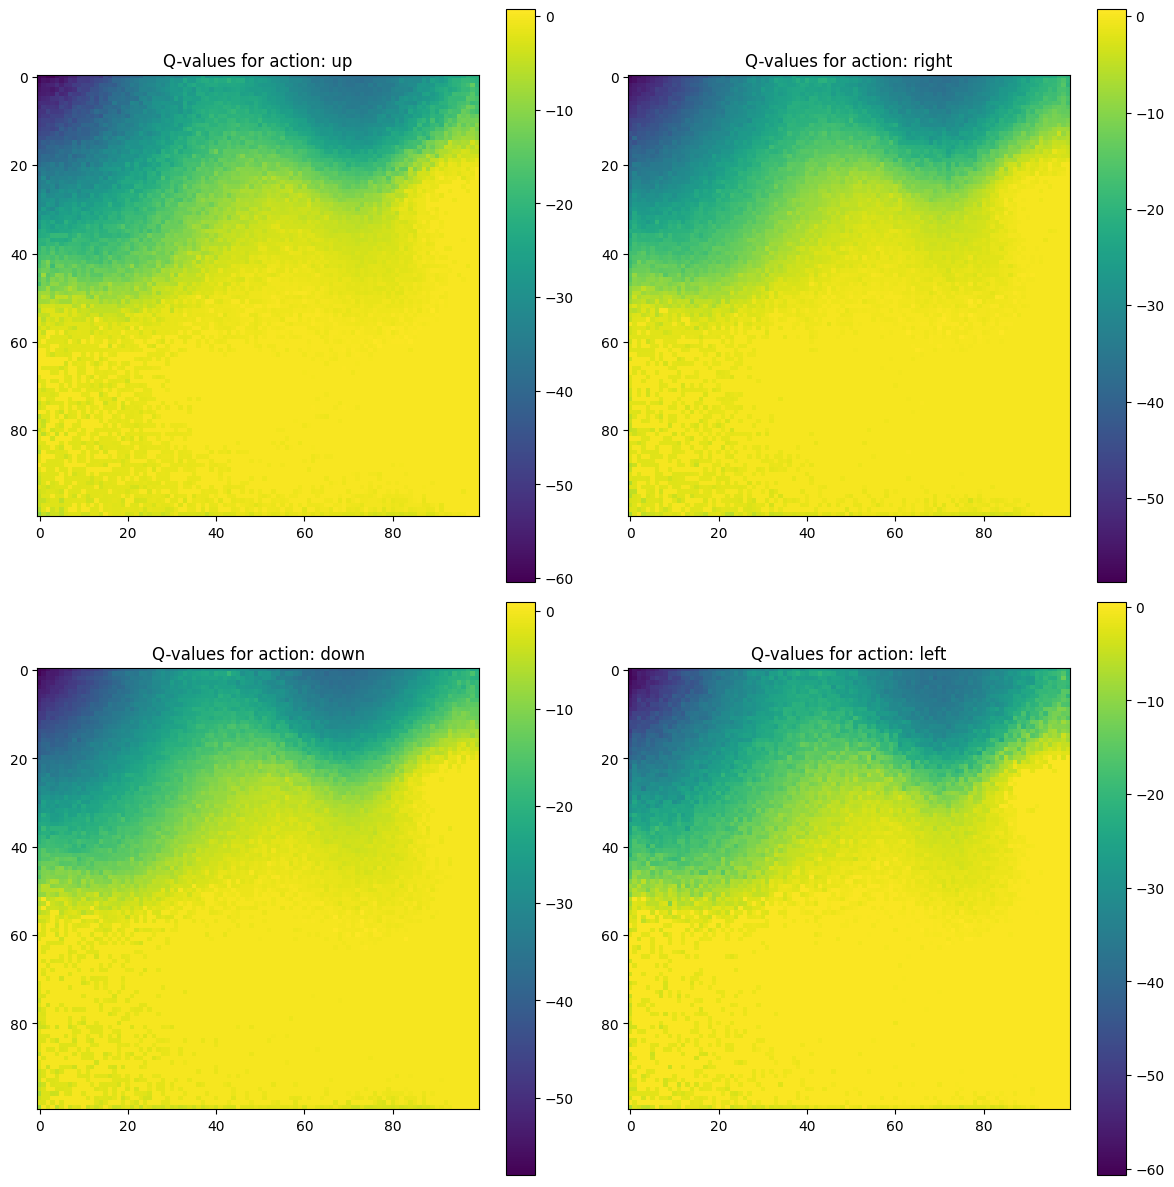

In [17]:
def visualize_q_values(Q):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    action_names = list(actions.keys())
    
    for i, ax in enumerate(axes.flatten()):
        im = ax.imshow(Q[:, :, i], cmap='viridis')
        ax.set_title(f"Q-values for action: {action_names[i]}")
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()

visualize_q_values(Q)

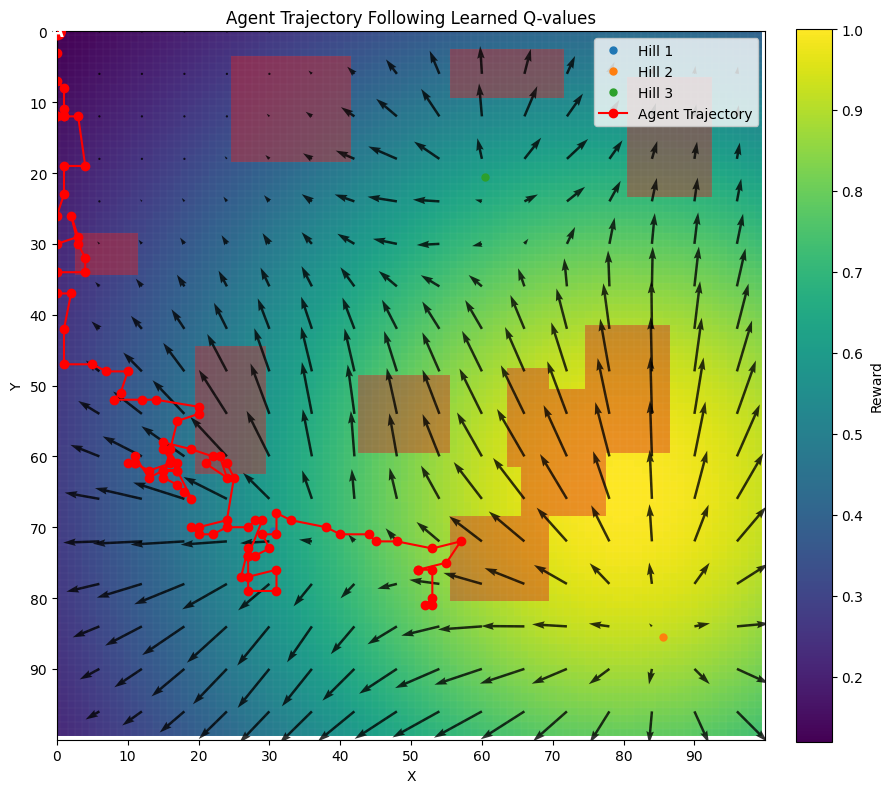

In [27]:
def plot_run(Q, env, start_state, max_steps=100):
    s = start_state
    trajectory = [s]
    
    for _ in range(max_steps):
        x, y = s
        a_index = np.argmax(Q[x, y, :])
        a = list(actions.values())[a_index]
        s = env.transition(s, a)
        trajectory.append(s)
        
        if distance_to_goal(s) < 5:
            break
    
    # Plot the trajectory
    fig, ax = plt.subplots(figsize=(10, 10))
    env.plot_combined(ax=ax)
    env.plot_hills(ax=ax)
    plot_agent(start_state, ax=ax)
    
    traj_x, traj_y = zip(*trajectory)
    ax.plot(traj_x, traj_y, marker='o', color='red', label='Agent Trajectory')
    ax.legend()
    plt.title("Agent Trajectory Following Learned Q-values")
    plt.show()

plot_run(Q, env, start_state)

In [ ]:
print(f"Unique states visited: {len(states_visited)}")

Unique states visited: 7320
